# Trivago Recommender System – Exploratory Data Analysis (EDA)

This notebook explores the Trivago dataset, including its structure, features, distributions, potential associations and data quality. The findings are used to inform subsequent decisions, including the definition of the research question, feature selection and engineering, data preprocessing, model selection, and model architecture.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%pip install seaborn missingno
import seaborn as sns
import scipy.stats as st
%pip install missingno
import missingno as msno

In [ ]:
# Load canonical complete-session samples

import os

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/PGDipAI/Modules/Module 5 -  ML/Final assignment/Files/"

sampled_train_sessions = pd.read_parquet(
    f"{DATA_PATH}/train_session_sample_10pct.parquet"
)

sampled_test_sessions = pd.read_parquet(
    f"{DATA_PATH}/test_session_sample_10pct.parquet"
)

metadata = pd.read_parquet(
    f"{DATA_PATH}/metadata.parquet"
)

print("Train sample:", sampled_train_sessions.shape)
print("Test sample:", sampled_test_sessions.shape)
print("Metadata:", metadata.shape)

Mounted at /content/drive
Train sample: (1568261, 12)
Test sample: (375153, 12)
Metadata: (927142, 3)


In [ ]:
# Load checkpoint after runtime restart

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/PGDipAI/Modules/Module 5 -  ML/Final assignment/Files/"

clickouts = pd.read_parquet(
    f"{DATA_PATH}/clickouts_sample.parquet"
)


metadata = pd.read_parquet(
    f"{DATA_PATH}/metadata.parquet"
)

candidates = pd.read_parquet(
    f"{DATA_PATH}/candidates.parquet"
)

# Load complete session-level sample checkpoints

sampled_train_sessions = pd.read_parquet(
    f"{DATA_PATH}/train_session_sample_10pct.parquet"
)

sampled_test_sessions = pd.read_parquet(
    f"{DATA_PATH}/test_session_sample_10pct.parquet"
)

session_events = pd.read_parquet(
    f"{DATA_PATH}/session_events_sample.parquet"
)

print("Checkpoint loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/PGDipAI/Modules/Module 5 -  ML/Final assignment/Files/"


In [ ]:
train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")
metadata = pd.read_csv(DATA_PATH + "item_metadata.csv")

In [ ]:
display(train.info())
display(test.info())
display(metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15932992 entries, 0 to 15932991
Data columns (total 12 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   user_id          object
 1   session_id       object
 2   timestamp        int64 
 3   step             int64 
 4   action_type      object
 5   reference        object
 6   platform         object
 7   city             object
 8   device           object
 9   current_filters  object
 10  impressions      object
 11  prices           object
dtypes: int64(2), object(10)
memory usage: 1.4+ GB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3782335 entries, 0 to 3782334
Data columns (total 12 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   user_id          object
 1   session_id       object
 2   timestamp        int64 
 3   step             int64 
 4   action_type      object
 5   reference        object
 6   platform         object
 7   city             object
 8   device           object
 9   current_filters  object
 10  impressions      object
 11  prices           object
dtypes: int64(2), object(10)
memory usage: 346.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927142 entries, 0 to 927141
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   item_id     927142 non-null  int64 
 1   properties  927142 non-null  object
dtypes: int64(1), object(1)
memory usage: 14.1+ MB


None

In [ ]:
train_sample.head(30)

,user_id,session_id,timestamp,step,action_type,reference,platform,city,device,current_filters,impressions,prices
595252,4HC2BPGWO81W,f656ae0a004aa,1541286406,3,filter selection,Sort by Price,MX,"Morelia, Mexico",mobile,Sort by Price,NaN,NaN
10111423,ZT4HHCS69JSM,736a2fcc25a07,1541437022,42,interaction item image,7206478,TR,"Alaçatı, Turkey",mobile,NaN,NaN,NaN
12254819,R75XX26J2FZV,50b6577e87661,1541354288,5,clickout item,55262,UK,"Cairo, Egypt",desktop,NaN,1380868|55262|5661892|121018|2363750|1555571|7...,164|140|47|80|75|119|67|48|111|78|80|60|238|55...
5269683,8YI53C9DIQ4J,b1da226adba61,1541263295,3,interaction item image,2446508,TW,"Taipei City, Taiwan",desktop,NaN,NaN,NaN
2045117,Y3KGME36X7DE,6a0f29015a8a1,1541445265,125,interaction item image,155287,ES,"Ávila, Spain",desktop,NaN,NaN,NaN
8782218,KAGS1H8UJ9E4,a6bf1e824b68f,1541315004,5,filter selection,4 Star,IN,"Mumbai, India",mobile,5 Star|4 Star,NaN,NaN
4848286,QC68J8J5KRTF,5f3ea67c84abd,1541442256,149,interaction item image,953783,RU,"Barcelona, Spain",mobile,NaN,NaN,NaN
5788629,YAU3EFL44DD4,22da11e3f7638,1541456906,8,interaction item image,140925,AA,"Hurghada, Egypt",mobile,NaN,NaN,NaN
6105797,1W5ZBUJ43J74,fcefc1c7b0b92,1541488699,330,interaction item image,93587,TW,"Moscow, Russia",desktop,NaN,NaN,NaN
11023099,PBTX02K8HK3S,6fb80a65e5434,1541095348,3,clickout item,2344168,BR,"Porto Seguro, Brazil",mobile,NaN,2344168|2813114|1473745|623246|479326|745041|2...,23|19|20|17|27|36|18|30|79|81|36|56|92|32|438|...


In [ ]:
# Display an example session showing the sequence of user interactions

session_example = (
    train[
        train["session_id"] == "c113341196c6f"
    ]
    .sort_values("step")
    [
        [
            "step",
            "action_type",
            "reference",
            "current_filters",
            "impressions"
        ]
    ]
    .reset_index(drop=True)
)

session_example

,step,action_type,reference,current_filters,impressions
0,1,clickout item,103600,NaN,3079114|103600|5452024|1554487|1814295|3143733...
1,2,clickout item,103600,NaN,3079114|103600|5452024|1554487|1814295|3143733...
2,3,filter selection,3 Star,3 Star,NaN
3,4,filter selection,4 Star,3 Star|4 Star,NaN
4,5,filter selection,5 Star,3 Star|4 Star|5 Star,NaN
...,...,...,...,...,...
67,68,interaction item deals,1871817,NaN,NaN
68,69,interaction item deals,1871817,NaN,NaN
69,70,clickout item,1871817,4 Star|5 Star|3 Star|Good Rating,2180114|2164494|1166237|1871817|7022438|877969...
70,71,clickout item,1871817,4 Star|5 Star|3 Star|Good Rating,2180114|2164494|1166237|1871817|7022438|877969...


In [ ]:
# Validate how a unique session should be identified

print(
    "Unique session_id:",
    train["session_id"].nunique()
)

print(
    "Unique user_id + session_id:",
    train[["user_id", "session_id"]]
    .drop_duplicates()
    .shape[0]
)

print(
    "Does session_id uniquely identify a session?",
    train["session_id"].nunique()
    ==
    train[["user_id", "session_id"]]
    .drop_duplicates()
    .shape[0]
)

Unique session_id: 910683
Unique user_id + session_id: 910683
Does session_id uniquely identify a session? True


**Sampling:**
The interaction dataset is large, so 10% of sessions are sampled for the analysis. Sampling is performed at the session level rather than the individual-row level to preserve the complete sequence of user interactions within each selected session. This is important because actions occurring before a ranking event may provide information about the user's current search intent.

In [ ]:
# Use 10% of complete sessions for EDA and model development

RANDOM_STATE = 42

# --------------------------------------------------
# Training data
# --------------------------------------------------

# Sample 10% of unique session IDs
sampled_train_session_ids = (
    train["session_id"]
    .dropna()
    .drop_duplicates()
    .sample(
        frac=0.10,
        random_state=RANDOM_STATE
    )
)

# Retain every interaction belonging to the selected sessions
sampled_train_sessions = train[
    train["session_id"].isin(sampled_train_session_ids)
].copy()

# Preserve interaction order within each session
sampled_train_sessions = sampled_train_sessions.sort_values(
    ["session_id", "step"]
).reset_index(drop=True)


# --------------------------------------------------
# Test data
# --------------------------------------------------

# Sample 10% of unique session IDs
sampled_test_session_ids = (
    test["session_id"]
    .dropna()
    .drop_duplicates()
    .sample(
        frac=0.10,
        random_state=RANDOM_STATE
    )
)

# Retain every interaction belonging to the selected sessions
sampled_test_sessions = test[
    test["session_id"].isin(sampled_test_session_ids)
].copy()

# Preserve interaction order within each session
sampled_test_sessions = sampled_test_sessions.sort_values(
    ["session_id", "step"]
).reset_index(drop=True)


# --------------------------------------------------
# Validate sampling
# --------------------------------------------------

print("Original train rows:", len(train))
print("Sample train rows:", len(sampled_train_sessions))
print("Original train sessions:", train["session_id"].nunique())
print(
    "Sample train sessions:",
    sampled_train_sessions["session_id"].nunique()
)

print("\nOriginal test rows:", len(test))
print("Sample test rows:", len(sampled_test_sessions))
print("Original test sessions:", test["session_id"].nunique())
print(
    "Sample test sessions:",
    sampled_test_sessions["session_id"].nunique()
)

train_original_counts = (
    train[
        train["session_id"].isin(
            sampled_train_sessions["session_id"].unique()
        )
    ]
    .groupby("session_id")
    .size()
)

train_sample_counts = (
    sampled_train_sessions
    .groupby("session_id")
    .size()
)

print(
    "All sampled train sessions complete:",
    train_original_counts.equals(train_sample_counts)
)


test_original_counts = (
    test[
        test["session_id"].isin(
            sampled_test_sessions["session_id"].unique()
        )
    ]
    .groupby("session_id")
    .size()
)

test_sample_counts = (
    sampled_test_sessions
    .groupby("session_id")
    .size()
)

print(
    "All sampled test sessions complete:",
    test_original_counts.equals(test_sample_counts)
)

Original train rows: 15932992
Sample train rows: 1568387
Original train sessions: 910683
Sample train sessions: 91068

Original test rows: 3782335
Sample test rows: 375153
Original test sessions: 291381
Sample test sessions: 29138
All sampled train sessions complete: True
All sampled test sessions complete: True


In [ ]:
# Validate that sampled sessions contain all original interaction rows

train_original_counts = (
    train[
        train["session_id"].isin(
            sampled_train_sessions["session_id"].unique()
        )
    ]
    .groupby("session_id")
    .size()
)

train_sample_counts = (
    sampled_train_sessions
    .groupby("session_id")
    .size()
)

print(
    "All sampled train sessions complete:",
    train_original_counts.equals(train_sample_counts)
)


test_original_counts = (
    test[
        test["session_id"].isin(
            sampled_test_sessions["session_id"].unique()
        )
    ]
    .groupby("session_id")
    .size()
)

test_sample_counts = (
    sampled_test_sessions
    .groupby("session_id")
    .size()
)

print(
    "All sampled test sessions complete:",
    test_original_counts.equals(test_sample_counts)
)

All sampled train sessions complete: True
All sampled test sessions complete: True


In [ ]:
# Checkpoint: Save complete session-level samples

sampled_train_sessions.to_parquet(
    f"{DATA_PATH}/train_session_sample_10pct.parquet",
    index=False
)

sampled_test_sessions.to_parquet(
    f"{DATA_PATH}/test_session_sample_10pct.parquet",
    index=False
)

print("Session-level checkpoints saved.")
print("Train:", sampled_train_sessions.shape)
print("Test:", sampled_test_sessions.shape)

Session-level checkpoints saved.
Train: (1568387, 12)
Test: (375153, 12)


In [ ]:
metadata.head(30)

,item_id,properties
0,5101,Satellite TV|Golf Course|Airport Shuttle|Cosme...
1,5416,Satellite TV|Cosmetic Mirror|Safe (Hotel)|Tele...
2,5834,Satellite TV|Cosmetic Mirror|Safe (Hotel)|Tele...
3,5910,Satellite TV|Sailing|Cosmetic Mirror|Telephone...
4,6066,Satellite TV|Sailing|Diving|Cosmetic Mirror|Sa...
5,6094,Satellite TV|Sailing|Safe (Hotel)|Telephone|Ho...
6,6288,Satellite TV|Airport Shuttle|Cosmetic Mirror|S...
7,6358,Cosmetic Mirror|Safe (Hotel)|Telephone|Hotel|C...
8,6456,Satellite TV|Cosmetic Mirror|Safe (Hotel)|Tele...
9,6561,Satellite TV|Golf Course|Cosmetic Mirror|Safe ...


In [ ]:
sampled_test_sessions.head(10)

,user_id,session_id,timestamp,step,action_type,reference,platform,city,device,current_filters,impressions,prices
0,P2L70S1Y60IF,0000059a39020,1541719950,1,clickout item,NaN,JP,"Sapporo, Japan",mobile,NaN,2251200|924581|4775012|10090928|2282660|895299...,54|42|64|51|62|42|61|54|53|56|54|53|57|59|44|4...
1,Z7BDMNH489W9,000338c4794e8,1541615050,1,search for destination,"Cancun, Mexico",CO,"Cancun, Mexico",desktop,NaN,NaN,NaN
2,Z7BDMNH489W9,000338c4794e8,1541615060,2,search for destination,"Jericó, Colombia",CO,"Jericó, Colombia",desktop,NaN,NaN,NaN
3,Z7BDMNH489W9,000338c4794e8,1541615076,3,clickout item,5574632,CO,"Jericó, Colombia",desktop,NaN,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
4,Z7BDMNH489W9,000338c4794e8,1541615120,4,clickout item,5887098,CO,"Jericó, Colombia",desktop,NaN,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
5,Z7BDMNH489W9,000338c4794e8,1541615143,5,clickout item,NaN,CO,"Jericó, Colombia",desktop,NaN,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
6,RJ7WHKZYN8Z8,00045397b909e,1541686381,1,clickout item,NaN,IT,"Forli, Italy",mobile,NaN,672876|148432|82675|3590410|152441|45034|83541...,65|67|69|109|48|86|73|49|55|70|48|64|52|55|55|...
7,1KTSH415A31G,000486f8640ae,1541699911,1,search for destination,"Fortaleza, Brazil",BR,"Fortaleza, Brazil",desktop,NaN,NaN,NaN
8,1KTSH415A31G,000486f8640ae,1541699951,2,clickout item,104867,BR,"Fortaleza, Brazil",desktop,NaN,104867|5032060|104773|127102|104634|104802|104...,60|64|74|89|48|58|70|56|66|64|48|58|66|86|301|...
9,1KTSH415A31G,000486f8640ae,1541699982,3,clickout item,NaN,BR,"Fortaleza, Brazil",desktop,NaN,104867|5032060|104773|127102|104634|104802|104...,60|64|74|89|48|58|70|56|66|64|48|58|66|86|301|...


In [ ]:
#Exploring action_type column
print(sampled_train_sessions["action_type"].unique())

['interaction item image' 'clickout item' 'search for item'
 'interaction item rating' 'search for destination' 'search for poi'
 'interaction item info' 'filter selection' 'change of sort order'
 'interaction item deals']


In [ ]:
#Exploring action_type and reference association
reference_exmples = (
    sampled_train_sessions.groupby("action_type")["reference"].apply(lambda x: x.dropna().unique()[:2])
)
print(reference_exmples)

action_type
change of sort order            [interaction sort button, price only]
clickout item                                       [109489, 4144478]
filter selection                           [Hotel Bar, Sort by Price]
interaction item deals                              [893693, 5191830]
interaction item image                                [109489, 46985]
interaction item info                              [3983674, 2216572]
interaction item rating                            [2897358, 3500566]
search for destination     [Campos do Jordão, Brazil, Maceió, Brazil]
search for item                                    [9804738, 3500566]
search for poi                         [El Rodadero, Arc de Triomphe]
Name: reference, dtype: object


In [ ]:
#Exploring deals action type
#search for item exploration
sort_exploration = sampled_train_sessions[sampled_train_sessions["action_type"] == "change of sort order"]

print(sort_exploration [ [
   "action_type", "reference"]].head(10))

               action_type                 reference
111   change of sort order   interaction sort button
112   change of sort order                price only
159   change of sort order   interaction sort button
160   change of sort order  distance and recommended
162   change of sort order   interaction sort button
950   change of sort order   interaction sort button
951   change of sort order  distance and recommended
1051  change of sort order   interaction sort button
1052  change of sort order                price only
1054  change of sort order   interaction sort button


In [ ]:
#Exploring filter action type
filter_exploration = sampled_train_sessions[sampled_train_sessions["action_type"] == "filter selection"]

print(filter_exploration [ [
   "action_type", "reference"]].head(10))

           action_type           reference
92    filter selection           Hotel Bar
113   filter selection       Sort by Price
161   filter selection   Focus on Distance
952   filter selection   Focus on Distance
1048  filter selection    Very Good Rating
1049  filter selection   Focus on Distance
1053  filter selection       Sort by Price
1056  filter selection   Focus on Distance
1085  filter selection  Breakfast Included
1221  filter selection  Serviced Apartment


Based on the exploration so far, features and references are represented as follows:

| Action type             | Representation interpretation                                                             | Reference                                                    |
| ----------------------- | ----------------------------------------------------------------------------------------- | ------------------------------------------------------------ |
| Search for POI          | A search for a point of interest associated with a destination                            | POI name                                                     |
| search for destination  | A search for a destination that is on a city/town + country level                         | City/town, and country name                                  |
| search for item         | Search for a specific property                                                            | property_id                                                  |
| interaction item image  | Interaction with images associated with a specific accommodation                          | property_id                                                  |
| Clickout item           | Click on an accommodation to view the deal on a partner website.                          | Property_id (potentially target feature for prediction)      |
| interaction item info   | Interaction with the info tab associated with a specific accommodation                    | property_id                                                  |
| interaction item deals  | Interaction with the a deals section associated with a specific accommodation             | property_id                                                  |
| filter selection        | Represents filters selected by the user on a specific search results page                 | Filter/s label/s                                             |
| interaction item rating | Click on the rating section (likely reviews tab) associated with a specific accommodation | property_id                                                  |
| change of sort order    | Interaction with the sort module, associated with a specific search results page          | click on the ‘sort’ button and specific sort method selected |



In [ ]:
#Exploring the clickout column
clickouts = sampled_train_sessions[sampled_train_sessions["action_type"] == "clickout item"]

print(clickouts [ [
    "user_id", "session_id", "step", "reference", "impressions", "prices"]].head())

        user_id     session_id  step reference  \
2  M2E4246PL9XQ  0002ccee5a980     3    109489   
3  7SIBY90KLDDS  0002d9458ab1c     1   4144478   
4  7SIBY90KLDDS  0002d9458ab1c     2   9482066   
6  1KH6YEB3SZCE  00030e90e12b2     1   1017368   
7  1KH6YEB3SZCE  00030e90e12b2     2   1390370   

                                         impressions  \
2  118737|1305086|4621782|1397441|53118|766713|92...   
3  42754|4144478|5516258|7930170|43124|399056|176...   
4  42754|4144478|5516258|7930170|43124|399056|176...   
6  1017368|1390370|9639742|9677664|8622816|104483...   
7  1017368|1390370|9639742|9677664|8622816|104483...   

                                              prices  
2  79|241|96|51|68|99|86|69|71|79|91|67|70|56|82|...  
3  61|53|64|46|57|56|50|45|72|51|40|43|11|38|58|4...  
4  61|53|64|46|57|56|50|45|72|51|40|43|11|38|58|4...  
6                433|180|124|168|153|141|115|106|105  
7                433|180|124|168|153|141|115|106|105  


In [ ]:
#Looking at clickout for a specific session
session = sampled_train_sessions[
    sampled_train_sessions["session_id"] == "aff3928535f48"]

print(session [ [
    "step", "action_type", "reference", "impressions", "prices"]].head(16))

         step             action_type    reference  \
1075628     1          search for poi      Newtown   
1075629     2  interaction item image       666856   
1075630     3  interaction item image       666856   
1075631     4  interaction item image       666856   
1075632     5  interaction item image       109038   
1075633     6  interaction item image       666856   
1075634     7  interaction item image       109038   
1075635     8  interaction item image       666856   
1075636     9  interaction item image       109038   
1075637    10  interaction item image       109038   
1075638    11  interaction item image       109038   
1075639    12  interaction item image       109038   
1075640    13  interaction item image       109038   
1075641    14           clickout item       109038   
1075642    15          search for poi  Surry Hills   
1075643    16           clickout item      1257342   

                                               impressions  \
1075628            

Based on the documentation, metadata item_id matches the property_id reference in the train dataset.
Seems like impressions represent the property candidate list, where in a session with a clickout action type, the reference includes a property id that exists in the impressions list.

In [ ]:
# How many property candidates are in an impressions list per clickout?

pd.set_option("display.float_format", "{:.2f}".format)

clickouts["num_impressions"] = clickouts["impressions"].str.split("|").str.len()

print(clickouts["num_impressions"].describe())

print(
    clickouts["num_impressions"].quantile([
        0.50, 0.75, 0.90, 0.95, 0.99
    ])
)

count   157809.00
mean        22.91
std          4.93
min          1.00
25%         25.00
50%         25.00
75%         25.00
max         25.00
Name: num_impressions, dtype: float64
0.50   25.00
0.75   25.00
0.90   25.00
0.95   25.00
0.99   25.00
Name: num_impressions, dtype: float64


/tmp/ipykernel_1286/3867347587.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clickouts["num_impressions"] = clickouts["impressions"].str.split("|").str.len()


In [ ]:
#Exploring metadata file
metadata[["item_id", "properties"]]
attributes = (metadata["properties"].dropna().str.split("|").explode()
             )
attribute_counts = attributes.value_counts()

print("Number of unique attributes:", attributes.nunique())
print("\nMost common attributes:")
print(attribute_counts.head(30))

Number of unique attributes: 157

Most common attributes:
properties
Satisfactory Rating         533286
Car Park                    487879
Good Rating                 481910
WiFi (Rooms)                467027
Shower                      426875
Television                  425953
WiFi (Public Areas)         399547
Hotel                       379321
Very Good Rating            376666
Air Conditioning            353296
House / Apartment           352254
Openable Windows            348151
Non-Smoking Rooms           346035
Free WiFi (Combined)        318894
Central Heating             315101
Fridge                      304854
Hairdryer                   300873
Free WiFi (Rooms)           293882
Desk                        276219
Free WiFi (Public Areas)    269060
Luxury Hotel                262400
From 2 Stars                250965
Self Catering               248731
Business Hotel              245433
Terrace (Hotel)             245405
Telephone                   239937
Restaurant           

In [ ]:
from numpy._core.defchararray import count
#full set of attribute names
print(sorted(attributes.unique()))


['1 Star', '2 Star', '3 Star', '4 Star', '5 Star', 'Accessible Hotel', 'Accessible Parking', 'Adults Only', 'Air Conditioning', 'Airport Hotel', 'Airport Shuttle', 'All Inclusive (Upon Inquiry)', 'Balcony', 'Bathtub', 'Beach', 'Beach Bar', 'Beauty Salon', 'Bed & Breakfast', 'Bike Rental', 'Boat Rental', 'Body Treatments', 'Boutique Hotel', 'Bowling', 'Bungalows', 'Business Centre', 'Business Hotel', 'Cable TV', 'Camping Site', 'Car Park', 'Casa Rural (ES)', 'Casino (Hotel)', 'Central Heating', 'Childcare', 'Club Hotel', 'Computer with Internet', 'Concierge', 'Conference Rooms', 'Convenience Store', 'Convention Hotel', 'Cosmetic Mirror', 'Cot', 'Country Hotel', 'Deck Chairs', 'Design Hotel', 'Desk', 'Direct beach access', 'Diving', 'Doctor On-Site', 'Eco-Friendly hotel', 'Electric Kettle', 'Excellent Rating', 'Express Check-In / Check-Out', 'Family Friendly', 'Fan', 'Farmstay', 'Fitness', 'Flatscreen TV', 'Free WiFi (Combined)', 'Free WiFi (Public Areas)', 'Free WiFi (Rooms)', 'Fridge',

In [ ]:
#Getting the complete list of filters used in a session from the train dataset
filters = (sampled_train_sessions["current_filters"].dropna().str.split("|").explode())

unique_filters = sorted(filters.unique())

print("Number of unique filters used in sessions:", len(unique_filters))
print(unique_filters)

Number of unique filters used in sessions: 144
['1 Star', '2 Star', '3 Nights', '3 Star', '4 Star', '5 Star', 'Accessible Hotel', 'Accessible Parking', 'Adults Only', 'Air Conditioning', 'Airport Hotel', 'Airport Shuttle', 'All Inclusive (Upon Inquiry)', 'Balcony', 'Bathtub', 'Beach', 'Beach Bar', 'Bed & Breakfast', 'Best Rates', 'Best Value', 'Boat Rental', 'Boutique Hotel', 'Breakfast Included', 'Bungalows', 'Business Centre', 'Business Hotel', 'Cable TV', 'Camping Site', 'Car Park', 'Casa Rural (ES)', 'Casino (Hotel)', 'Central Heating', 'Cheap', 'Childcare', 'Conference Rooms', 'Cot', 'Country Hotel', 'Deals + Beach (MX)', 'Deals + Beach (PT)', 'Deals + Beach (TR)', 'Desk', 'Direct beach access', 'Disneyland', 'Disneyland Paris', 'Eco-Friendly hotel', 'Electric Kettle', 'Excellent Rating', 'Express Check-In / Check-Out', 'Family Friendly', 'Farmstay', 'Fitness', 'Flatscreen TV', 'Focus on Distance', 'Focus on Rating', 'Free WiFi (Combined)', 'Free WiFi (Public Areas)', 'Free WiFi (

In [ ]:
# Looking at filter usage frequency in sessions
filter_counts = filters.value_counts()

print(filter_counts.to_string())

current_filters
Hotel                              34447
5 Star                             26895
Resort                             25457
Sort by Price                      25425
4 Star                             25215
Hostal (ES)                        21045
Motel                              20708
Focus on Distance                  19258
3 Star                             15036
Best Value                         10744
Free WiFi (Combined)                9079
Very Good Rating                    8186
Breakfast Included                  7083
Excellent Rating                    6303
Car Park                            5793
Swimming Pool (Combined Filter)     5708
Good Rating                         5334
House / Apartment                   5012
2 Star                              4187
Air Conditioning                    3788
Serviced Apartment                  3566
Sort By Distance                    3446
Spa (Wellness Facility)             2988
Focus on Rating                     2556



## Learnings so far and direction for the recommender system
So far, the initial exploration has shown that:
1. The train dataset contains user-session interactions and search context, while the item_metadata dataset contains attributes describing individual accommodation properties.
2. For clickout item actions, the reference identifies the accommodation selected by the user from the corresponding impressions candidate list. This provides an implicit relevance signal: one candidate was clicked from the displayed set.
3. The test dataset follows the same structure as the training dataset, but the target clickout reference is missing for the final clickout event in a session. Given that this dataset is part of a competition, this indicates that the task is to predict the accommodation selected for these target events.
4. There is substantial overlap between values in current_filters and the property attributes available in item_metadata. However, the filter vocabulary is broader than the metadata property attribute vocabulary. This means that some search filters may be directly matched to candidate attributes, while others cannot.

### Direction for the recommender system
Industry literature describes recommender systems as commonly consisting of separate candidate-generation and ranking stages (Covington, Adams and Sargin, 2016; Adamczak et al., 2020; Nan, Parthasarathy and Wang, 2023; Zaidi, Rincon and Hassantabar, 2026). Candidate generation retrieves a manageable set of potentially relevant items, after which a ranking system uses richer contextual and item information to order those candidates. The accommodation recommendation literature reviewed similarly separates candidate generation from downstream ranking.

The Trivago dataset already provides the candidate set through impressions. Therefore, this project will focus on the ranking stage, rather than candidate generation:

- Provided candidate set (impressions), use preceding session behaviour, search context and candidate property attributes to estimate candidate relevance, rank candidates, evaluate whether the clicked accommodation is ranked highly.

- A session may contain multiple clickout events. Each clickout will therefore be treated as a separate ranking event. For each ranking event, only information available before or at that event will be used as predictors, avoiding the use of subsequent interactions that would introduce target leakage. This allows the model to incorporate the user's evolving within-session behaviour and search intent.

- The dataset does not provide rich long-term user information such as demographics, travelling group or past bookings. However, it does provide behavioural information within the current session. The recommender will therefore primarily use current-session context and behaviour, together with candidate accommodation information, rather than relying on a persistent historical user profile.



# EDA

The following exploratory data analysis supports the chosen direction for the recommender system.

Since the objective is to rank the accommodation candidates available at each ranking event, the analysis will focus on information that would be available at the time of ranking. This includes preceding session behaviour, search context and candidate accommodation attributes. For each ranking event, only session interactions occurring before or at that event will be considered as potential predictors to avoid target leakage.

**Potential information available at ranking time:** search context (destination, POI or accommodation search), active filters, sort order, candidate list (impressions), candidate prices, candidate position and candidate property attributes.

We'll review:
1. Data quality (Missingness, duplicates, data types, structural integrity)
2. Distributions and cardinality for some relevant features
3. Relationships and associations between potential ranking features, using statistical measures appropriate to each data type, to identify redundancy and potentially informative relationships.
4. Search context vs. clickout property characteristics
5. Candidate attributes vs. clickout
6. Price analysis: examine absolute and contextual price distributions, including differences by destination/property characteristics and candidate price relative to other accommodations in the same impression set.

*Some steps above will involve some feature engineering, which might later be used in the recommender system.*

### 1. Data quality:

In [ ]:
#Missing data for the train dataset
missing = pd.DataFrame({
    "missing_count": sampled_train_sessions.isnull().sum(),
    "missing_percent": sampled_train_sessions.isnull().mean() * 100
})

print(missing.sort_values("missing_percent", ascending=False))

                 missing_count  missing_percent
current_filters        1454702            92.76
impressions            1410452            89.94
prices                 1410452            89.94
user_id                      0             0.00
step                         0             0.00
timestamp                    0             0.00
session_id                   0             0.00
action_type                  0             0.00
city                         0             0.00
platform                     0             0.00
reference                    0             0.00
device                       0             0.00


In [ ]:
#Checking for duplications

#return true if all columns in row are identical
sampled_train_sessions.duplicated().sum()

np.int64(0)

In [ ]:
#Missing data for the metadata dataset
missing_meta = pd.DataFrame({
    "missing_count": metadata.isnull().sum(),
    "missing_percent": metadata.isnull().mean() * 100
})

print(missing_meta.sort_values("missing_percent", ascending=False))

                missing_count  missing_percent
item_id                     0             0.00
properties                  0             0.00
num_properties              0             0.00


In [ ]:
#Checking for duplications in metadata dataset

#return the number of duplicated accommodations in list
metadata["item_id"].duplicated().sum()

np.int64(0)

In [ ]:
#Does every clickout have an impression and a price list?
clickouts = sampled_train_sessions.loc[
    sampled_train_sessions["action_type"] == "clickout item"
].copy()

print("Total clickouts:", len(clickouts))
print("Clickouts missing impressions:", clickouts["impressions"].isna().sum())
print("Clickouts missing prices:", clickouts["prices"].isna().sum())

Total clickouts: 157809
Clickouts missing impressions: 0
Clickouts missing prices: 0


In [ ]:
#Do impressions and prices have the same number of items?
clickouts["num_impressions"] = (
    clickouts["impressions"].str.split("|").str.len()
)

clickouts["num_prices"] = (
    clickouts["prices"].str.split("|").str.len()
)

price_alignment = (
    clickouts["num_impressions"] == clickouts["num_prices"]
)

print("Matching impression/price lengths:", price_alignment.mean() * 100, "%")
print("Mismatched rows:", (~price_alignment).sum())

Matching impression/price lengths: 100.0 %
Mismatched rows: 0


In [ ]:
#Is the clickout item always present in the candidate list?
clickouts["clicked_in_impressions"] = clickouts.apply(
    lambda row: str(row["reference"]) in str(row["impressions"]).split("|"),
    axis=1
)

print(
    "Clicked item found in impressions:",
    clickouts["clicked_in_impressions"].mean() * 100,
    "%"
)

Clicked item found in impressions: 99.94740477412569 %


In [ ]:
# Missing values in test data
test_missing = pd.DataFrame({
    "missing_count": sampled_test_sessions.isnull().sum(),
    "missing_percent": sampled_test_sessions.isnull().mean() * 100
})

test_missing

,missing_count,missing_percent
user_id,0,0.00
session_id,0,0.00
timestamp,0,0.00
step,0,0.00
action_type,0,0.00
reference,26140,6.97
platform,0,0.00
city,0,0.00
device,0,0.00
current_filters,340891,90.87


In [ ]:
#Digging into the missing references
sampled_test_sessions.loc[
    sampled_test_sessions["reference"].isna(),
    "action_type"
].value_counts()

,count
action_type,
clickout item,25344
interaction item image,446
filter selection,76
search for destination,54
interaction item deals,52
change of sort order,49
interaction item rating,40
interaction item info,32
search for item,29


In [ ]:
#isolating the missing rows in test
test_missing_clickout = sampled_test_sessions[
    (sampled_test_sessions["action_type"] == "clickout item") &
    (sampled_test_sessions["reference"].isna())
]

print("Missing-reference clickouts:", len(test_missing_clickout))

print("\nMissingness:")
print(
    test_missing_clickout[
        ["reference", "impressions", "prices"]
    ].isna().sum()
)

Missing-reference clickouts: 25344

Missingness:
reference      25344
impressions        0
prices             0
dtype: int64


In [ ]:
#have a closer look
test_missing_clickout[
    [
        "user_id",
        "session_id",
        "timestamp",
        "step",
        "reference",
        "impressions",
        "prices"
    ]
].head()

,user_id,session_id,timestamp,step,reference,impressions,prices
0,P2L70S1Y60IF,0000059a39020,1541719950,1,None,2251200|924581|4775012|10090928|2282660|895299...,54|42|64|51|62|42|61|54|53|56|54|53|57|59|44|4...
5,Z7BDMNH489W9,000338c4794e8,1541615143,5,None,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
6,RJ7WHKZYN8Z8,00045397b909e,1541686381,1,None,672876|148432|82675|3590410|152441|45034|83541...,65|67|69|109|48|86|73|49|55|70|48|64|52|55|55|...
9,1KTSH415A31G,000486f8640ae,1541699982,3,None,104867|5032060|104773|127102|104634|104802|104...,60|64|74|89|48|58|70|56|66|64|48|58|66|86|301|...
54,PVAPDRRM1BER,000737a92bc59,1541590350,43,None,2670033|3144968|2734272|2877924|3053700|399577...,98|71|74|98|115|79|86|65|123|93|67|72|62|121|7...


In [ ]:
#Checking for a specific session with missing data
sampled_test_sessions[sampled_test_sessions["session_id"] == "000338c4794e8"][
    [
        "user_id",
        "session_id",
        "timestamp",
        "step",
        "action_type",
        "reference",
        "impressions",
        "prices"
    ]
].sort_values("step")

,user_id,session_id,timestamp,step,action_type,reference,impressions,prices
1,Z7BDMNH489W9,000338c4794e8,1541615050,1,search for destination,"Cancun, Mexico",NaN,NaN
2,Z7BDMNH489W9,000338c4794e8,1541615060,2,search for destination,"Jericó, Colombia",NaN,NaN
3,Z7BDMNH489W9,000338c4794e8,1541615076,3,clickout item,5574632,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
4,Z7BDMNH489W9,000338c4794e8,1541615120,4,clickout item,5887098,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39
5,Z7BDMNH489W9,000338c4794e8,1541615143,5,clickout item,NaN,3953190|8268290|10598542|5060264|5574632|58870...,53|56|33|44|49|60|72|36|21|51|13|39


Missing reference in test file seems to indicate a deliberate exclusion of data, to perhaps serve for testing the prediction of this specific variable

In [ ]:
#Are the iterms in the candidate lists existing in the metadata list?
# Extract unique candidate IDs from impression lists
candidate_ids = (
    clickouts["impressions"]
    .dropna()
    .str.split("|")
    .explode()
    .unique()
)

print("Unique candidates in impressions:", len(candidate_ids))

Unique candidates in impressions: 417894


In [ ]:
#Comparing unique candidate list with metadata list
metadata_ids = set(metadata["item_id"].astype(str))

candidate_ids_str = pd.Series(candidate_ids).astype(str)

metadata_match = candidate_ids_str.isin(metadata_ids)

print("Candidates with metadata:", metadata_match.sum())
print("Candidates without metadata:", (~metadata_match).sum())
print("Metadata coverage:", metadata_match.mean() * 100, "%")

Candidates with metadata: 417559
Candidates without metadata: 335
Metadata coverage: 99.91983613069343 %


No true duplicate records were identified in either the training or metadata datasets. Missing values were found primarily in fields that are only populated for specific interaction types, indicating structural rather than unexpected missingness. Overall structural integrity was high: candidate and price lists were correctly aligned, clickout references were consistent with the corresponding candidate lists, and 99.91% of unique candidates could be matched to property metadata.

Overall, the data quality and structural integrity support the scoped recommender system.

## 2. Distribution and Cardinality

In [ ]:
## Cardinality for the simple categorical features
for col in ["city", "platform", "device"]:
    print(f"{col}: {sampled_train_sessions[col].nunique()} unique values")

city: 14147 unique values
platform: 55 unique values
device: 3 unique values


In [ ]:
#Distribution of the simple categorical features
for col in ["device", "platform", "city"]:
    print(f"\n{col.upper()}")
    print(sampled_train_sessions[col].value_counts(normalize=True).head(20) * 100)


DEVICE
device
mobile    47.69
desktop   43.91
tablet     8.40
Name: proportion, dtype: float64

PLATFORM
platform
BR   15.85
US   10.41
UK    6.31
DE    6.11
MX    5.37
IN    4.59
TR    3.45
AU    3.44
JP    3.21
IT    3.06
MY    2.99
ES    2.97
AR    2.89
CA    2.60
FR    2.28
NL    1.87
RU    1.71
CO    1.62
PL    1.11
PH    1.03
Name: proportion, dtype: float64

CITY
city
London, United Kingdom        2.16
Paris, France                 1.80
New York, USA                 1.50
Istanbul, Turkey              1.41
Cancun, Mexico                1.17
Amsterdam, Netherlands        1.11
Rio de Janeiro, Brazil        1.02
Tokyo, Japan                  0.87
Rome, Italy                   0.83
Dubai, United Arab Emirates   0.82
Berlin, Germany               0.80
Barcelona, Spain              0.76
Las Vegas, USA                0.73
São Paulo, Brazil             0.68
Madrid, Spain                 0.65
Kuala Lumpur, Malaysia        0.55
Prague, Czech Republic        0.55
Florianópolis, Brazil     

In [ ]:
#Explore filter distribution and cardninality
print("Unique filters:", filters. nunique())

filter_distribution = filters.value_counts()

print(filter_distribution.head(20))

Unique filters: 144
current_filters
Hotel                              34447
5 Star                             26895
Resort                             25457
Sort by Price                      25425
4 Star                             25215
Hostal (ES)                        21045
Motel                              20708
Focus on Distance                  19258
3 Star                             15036
Best Value                         10744
Free WiFi (Combined)                9079
Very Good Rating                    8186
Breakfast Included                  7083
Excellent Rating                    6303
Car Park                            5793
Swimming Pool (Combined Filter)     5708
Good Rating                         5334
House / Apartment                   5012
2 Star                              4187
Air Conditioning                    3788
Name: count, dtype: int64


In [ ]:
#Checking how many filters are relevant for an individual ranking event
clickouts["num_filters"] = (
    clickouts["current_filters"].fillna("").apply(lambda x: 0 if x == "" else len(x.split("|")))
)

clickouts["num_filters"].describe()

,num_filters
count,157809.00
mean,0.48
std,1.23
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,13.00


In [ ]:
#Number of attribute per accommodation
metadata["num_properties"] = (
    metadata["properties"]
    .fillna("")
    .apply(lambda x: 0 if x == "" else len(x.split("|")))
)

metadata["num_properties"].describe()

,num_properties
count,927142.00
mean,19.70
std,18.41
min,1.00
25%,3.00
50%,15.00
75%,32.00
max,112.00


In [ ]:
#Checking how many platforms are relevant for an individual ranking event
print("Unique platforms:", clickouts["platform"].nunique())

platform_distribution = (
    clickouts["platform"]
    .value_counts(normalize=True)
    .mul(100)
)

print(platform_distribution.to_string())

Unique platforms: 55
platform
BR   11.87
US    9.32
JP    7.71
UK    6.58
DE    6.12
IN    4.75
MX    3.89
IT    3.79
AU    3.60
ES    3.38
TR    3.26
CA    2.65
MY    2.60
FR    2.58
AR    2.47
RU    2.17
NL    1.59
PL    1.58
PH    1.20
CO    1.17
TW    1.05
HK    0.95
IE    0.93
SE    0.89
NZ    0.87
ZA    0.80
GR    0.74
CH    0.70
PT    0.69
IL    0.69
AT    0.67
BE    0.66
TH    0.65
FI    0.60
SG    0.59
RO    0.55
AA    0.52
DK    0.51
NO    0.50
KR    0.49
HU    0.46
CL    0.45
BG    0.40
CZ    0.40
PE    0.33
EC    0.27
ID    0.24
AE    0.24
RS    0.20
UY    0.19
SK    0.17
VN    0.13
HR    0.11
SI    0.07
CN    0.02


In [ ]:
print("Unique cities:", clickouts["city"].nunique())
print(clickouts["city"].value_counts(normalize=True).head(20) * 100)

Unique cities: 12320
city
London, United Kingdom        1.81
Tokyo, Japan                  1.51
New York, USA                 1.29
Paris, France                 1.21
Istanbul, Turkey              0.95
Amsterdam, Netherlands        0.87
Las Vegas, USA                0.86
Osaka, Japan                  0.85
Rome, Italy                   0.68
Madrid, Spain                 0.66
Rio de Janeiro, Brazil        0.61
Berlin, Germany               0.61
Cancun, Mexico                0.56
Dubai, United Arab Emirates   0.55
Barcelona, Spain              0.51
Prague, Czech Republic        0.49
São Paulo, Brazil             0.49
Sydney, Australia             0.47
Melbourne, Australia          0.45
Hong Kong, Hong Kong          0.45
Name: proportion, dtype: float64


#### Conclusions from skewness and cardinality:
**City:**
City is a high-cardinality categorical feature, containing 12,320 unique values. The distribution is highly dispersed: the most frequent city, London, represents only 1.8% of potential ranking events, and no individual city dominates the dataset. This suggests that directly representing each city as a separate categorical feature could result in a high-dimensional and sparse representation.

**Platform:**
Platform contains 55 unique values, with representation varying considerably across platforms. Unlike city, its cardinality is relatively limited and several platforms account for substantial proportions of potential ranking events. Platform can therefore reasonably be retained as a categorical contextual feature, although differences in representation should be considered during later evaluation.

**Device**
Device is a low-cardinality categorical feature with three categories. Mobile (47.69%) and desktop (43.91%) are similarly represented, while tablet accounts for 8.07% of potential ranking events. The feature therefore has no significant sparsity or high-cardinality concerns and can be retained as a contextual feature.


**Filter:**
Filter usage is sparse across potential ranking events. At least 75% of clickout events have no active filters, while the mean is 0.49 filters per event and the maximum is 18. Among events where filters are used, their frequency is highly uneven, with a relatively small number of filters accounting for much of the observed usage. This suggests that filters may provide a strong expression of search intent when present, but cannot be relied upon as a consistently available ranking signal.

## 3. Relationships and associations between potential ranking features:

In [ ]:
#Checking association using Cramer's V, as we're comparing 2 categorical features
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape

    return np.sqrt(
        (chi2 / n) / min(k - 1, r - 1)
    )

In [ ]:
#Association between city and platform
print(
    "Platform × City:",
    cramers_v(clickouts["platform"], clickouts["city"])
)

Platform × City: 0.7334312770765756


In [ ]:
#Association between device and platform
print(
    "Device × City:",
    cramers_v(clickouts["platform"], clickouts["device"])
)

Device × City: 0.18999387723606803


A Cramér's V of 0.723 indicates a strong association between platform and destination city, suggesting that the distribution of searched destinations differs substantially across platforms. Since 'platform' represents countries, this association makes sense.

The association between platform and device was relatively weak (Cramér's V = 0.184), suggesting that the two features capture largely different aspects of the search context and are unlikely to be redundant.

To check associations with the predicted value, we first need to create a table on the candidate level. This will also support step 4 in our EDA process.

In [ ]:
#Creating a unique identifier for each potential ranking event
clickouts["ranking_event_id"] = (
    clickouts["session_id"].astype(str) #ensuring it's a string
    +"_"
    + clickouts["step"].astype(str)
)

In [ ]:
#Validating the new column - the following should be identical
print("Clickout rows:", len(clickouts))
print("Unique ranking events:", clickouts["ranking_event_id"].nunique())

Clickout rows: 157809
Unique ranking events: 157809


In [ ]:
# Investigate duplicate ranking event identifiers

duplicate_ranking_events = clickouts[
    clickouts.duplicated(
        subset=["session_id", "step"],
        keep=False
    )
].sort_values(
    ["session_id", "step", "timestamp"]
)

print(
    "Rows involved in duplicate session_id + step combinations:",
    len(duplicate_ranking_events)
)

print(
    "Duplicate session_id + step combinations:",
    duplicate_ranking_events[
        ["session_id", "step"]
    ].drop_duplicates().shape[0]
)

duplicate_ranking_events[
    [
        "user_id",
        "session_id",
        "timestamp",
        "step",
        "action_type",
        "reference",
        "impressions",
        "prices"
    ]
]

Rows involved in duplicate session_id + step combinations: 0
Duplicate session_id + step combinations: 0


,user_id,session_id,timestamp,step,action_type,reference,impressions,prices


In [ ]:
# Remove the 5 sessions with ambiguous repeated clickout steps

ambiguous_session_ids = (
    clickouts.loc[
        clickouts.duplicated(
            subset=["session_id", "step"],
            keep=False
        ),
        "session_id"
    ]
    .unique()
)

print("Ambiguous sessions removed:", len(ambiguous_session_ids))

sampled_train_sessions = sampled_train_sessions[
    ~sampled_train_sessions["session_id"].isin(
        ambiguous_session_ids
    )
].copy()

# Recreate clickouts after removing the affected sessions
clickouts = sampled_train_sessions.loc[
    sampled_train_sessions["action_type"] == "clickout item"
].copy()

print("Remaining sessions:", sampled_train_sessions["session_id"].nunique())
print("Remaining clickouts:", len(clickouts))

Ambiguous sessions removed: 0
Remaining sessions: 91063
Remaining clickouts: 157809


In [ ]:
# Recreate ranking-event identifier after removing ambiguous sessions

clickouts["ranking_event_id"] = (
    clickouts["session_id"].astype(str)
    + "_"
    + clickouts["step"].astype(str)
)

print("Clickout rows:", len(clickouts))
print("Unique ranking events:", clickouts["ranking_event_id"].nunique())

Clickout rows: 157809
Unique ranking events: 157809


In [ ]:
# Checkpoint: save corrected sessions and ranking events

sampled_train_sessions.to_parquet(
    f"{DATA_PATH}/train_sessions_corrected.parquet",
    index=False
)

clickouts.to_parquet(
    f"{DATA_PATH}/clickouts_corrected.parquet",
    index=False
)

print("Corrected session and ranking-event checkpoints saved.")
print("Sessions:", sampled_train_sessions["session_id"].nunique())
print("Ranking events:", clickouts["ranking_event_id"].nunique())

Corrected session and ranking-event checkpoints saved.
Sessions: 91063
Ranking events: 157809


In [ ]:
#Convert the pipe-separeted string into aligned python lists
clickouts["candidate_id"] = clickouts["impressions"].str.split("|")
clickouts["candidate_price"] = clickouts["prices"].str.split("|")

In [ ]:
#Create a candidate ID position
clickouts["candidate_position"] = clickouts["candidate_id"].apply(
    lambda x: list(range(1, len(x) + 1))
)

In [ ]:
# Explore session interactions occurring before each ranking event

# Keep the ranking-event location within each session
ranking_points = clickouts[
    ["ranking_event_id", "session_id", "step"]
].copy()

# Join each ranking event to all interactions from the same session
preceding_interactions = ranking_points.merge(
    sampled_train_sessions,
    on="session_id",
    how="left",
    suffixes=("_ranking", "_interaction")
)

# Retain only interactions occurring BEFORE the ranking event
preceding_interactions = preceding_interactions[
    preceding_interactions["step_interaction"]
    < preceding_interactions["step_ranking"]
].copy()

print(
    "Ranking events:",
    clickouts["ranking_event_id"].nunique()
)

print(
    "Ranking events with preceding interactions:",
    preceding_interactions["ranking_event_id"].nunique()
)

print("\nPreceding interaction types:")
print(
    preceding_interactions["action_type"]
    .value_counts()
)

print("\nPercentage of ranking events with each preceding action type:")

action_coverage = (
    preceding_interactions
    .drop_duplicates(
        ["ranking_event_id", "action_type"]
    )
    ["action_type"]
    .value_counts()
    .div(clickouts["ranking_event_id"].nunique())
    .mul(100)
    .round(2)
)

print(action_coverage)

Ranking events: 157809
Ranking events with preceding interactions: 126876

Preceding interaction types:
action_type
interaction item image     1741910
clickout item               226367
filter selection            133076
change of sort order         81198
search for destination       73588
interaction item info        38183
interaction item rating      31813
search for poi               28018
search for item              23851
interaction item deals       23235
Name: count, dtype: int64

Percentage of ranking events with each preceding action type:
action_type
clickout item             47.62
interaction item image    36.69
search for destination    32.61
filter selection          24.51
change of sort order      15.62
interaction item info     13.72
search for poi            12.69
interaction item rating   11.79
search for item            9.93
interaction item deals     9.08
Name: count, dtype: float64


26,876 of 157,809 ranking events (80.4%) have at least one preceding interaction, so session history is available for the large majority of ranking events.

In [ ]:
# Create one row per candidate within each ranking event
candidates = clickouts.explode(
    ["candidate_id", "candidate_price", "candidate_position"],
    ignore_index=True
)

In [ ]:
#Validate the explosion worked as expected
print("Clickout events:", len(clickouts))
print("Candidate rows:", len(candidates))

candidates[
    [
        "ranking_event_id",
        "candidate_id",
        "candidate_price",
        "candidate_position",
        "reference"
    ]
].head(30)

Clickout events: 157809
Candidate rows: 3616016


,ranking_event_id,candidate_id,candidate_price,candidate_position,reference
0,0002ccee5a980_3,118737,79,1,109489
1,0002ccee5a980_3,1305086,241,2,109489
2,0002ccee5a980_3,4621782,96,3,109489
3,0002ccee5a980_3,1397441,51,4,109489
4,0002ccee5a980_3,53118,68,5,109489
5,0002ccee5a980_3,766713,99,6,109489
6,0002ccee5a980_3,9280852,86,7,109489
7,0002ccee5a980_3,108091,69,8,109489
8,0002ccee5a980_3,4083926,71,9,109489
9,0002ccee5a980_3,339541,79,10,109489


In [ ]:
#Create a binary feature to indicate which of the candidates was clicked in the session
candidates["clicked"] = (
    candidates["candidate_id"].astype(str) == candidates["reference"].astype(str)).astype(int)

In [ ]:
#Validate new column
clicked_per_event = (
    candidates
    .groupby("ranking_event_id")["clicked"]
    .sum()
)

print(clicked_per_event.value_counts())

clicked
1    157726
0        83
Name: count, dtype: int64


In the following code we're creating a ranking event map.
Each ranking event is associated with the most recent sequence of non-clickout interactions preceding it. If multiple clickouts occur consecutively, they all inherit that same preceding behavioural sequence.

In [ ]:
# Associate each ranking event with its most recent preceding behavioural sequence

session_events = sampled_train_sessions.sort_values(
    ["session_id", "step"]
).copy()

# Identify clickout rows
session_events["is_clickout"] = (
    session_events["action_type"] == "clickout item"
)

# A new behavioural sequence starts when a non-clickout interaction
# follows a clickout
previous_was_clickout = (
    session_events
    .groupby("session_id")["is_clickout"]
    .shift(fill_value=False)
)

session_events["new_behaviour_sequence"] = (
    (~session_events["is_clickout"])
    & previous_was_clickout
)

# Number behavioural sequences within each session
session_events["behaviour_sequence"] = (
    session_events
    .groupby("session_id")["new_behaviour_sequence"]
    .cumsum()
)

# Add ranking_event_id to clickout rows
ranking_event_map = clickouts[
    ["session_id", "step", "ranking_event_id"]
]

session_events = session_events.merge(
    ranking_event_map,
    on=["session_id", "step"],
    how="left"
)

In [ ]:
# Validate interaction-to-ranking-event assignment

print(
    "Ranking events represented:",
    session_events["ranking_event_id"].nunique()
)

print(
    "Expected ranking events:",
    clickouts["ranking_event_id"].nunique()
)

session_events[
    [
        "session_id",
        "step",
        "action_type",
        "reference",
        "ranking_event_id"
    ]
].head(30)

Ranking events represented: 157809
Expected ranking events: 157809


,session_id,step,action_type,reference,ranking_event_id
0,0002ccee5a980,1,interaction item image,109489,NaN
1,0002ccee5a980,2,interaction item image,109489,NaN
2,0002ccee5a980,3,clickout item,109489,0002ccee5a980_3
3,0002d9458ab1c,1,clickout item,4144478,0002d9458ab1c_1
4,0002d9458ab1c,2,clickout item,9482066,0002d9458ab1c_2
5,0002d9458ab1c,3,search for item,9804738,NaN
6,00030e90e12b2,1,clickout item,1017368,00030e90e12b2_1
7,00030e90e12b2,2,clickout item,1390370,00030e90e12b2_2
8,00030e90e12b2,3,clickout item,7905368,00030e90e12b2_3
9,00056fee0c63f,1,clickout item,853281,00056fee0c63f_1


In [ ]:
# Check interactions that are not followed by another ranking event

unassigned_events = session_events[
    session_events["ranking_event_id"].isna()
]

print("Unassigned interaction rows:", len(unassigned_events))
print(
    "Sessions with unassigned interactions:",
    unassigned_events["session_id"].nunique()
)

print("\nAction types:")
print(
    unassigned_events["action_type"].value_counts()
)

Unassigned interaction rows: 1410445
Sessions with unassigned interactions: 67702

Action types:
action_type
interaction item image     1163917
filter selection             68127
search for destination       40316
change of sort order         39774
interaction item info        27806
interaction item rating      21694
interaction item deals       19457
search for item              15639
search for poi               13715
Name: count, dtype: int64


In [ ]:
# Check how many sampled sessions contain no clickout event

all_sessions = set(
    sampled_train_sessions["session_id"].unique()
)

sessions_with_clickout = set(
    clickouts["session_id"].unique()
)

sessions_without_clickout = (
    all_sessions - sessions_with_clickout
)

print("Total sampled sessions:", len(all_sessions))
print("Sessions with a clickout:", len(sessions_with_clickout))
print("Sessions without a clickout:", len(sessions_without_clickout))

print(
    "Percentage without clickout:",
    round(
        len(sessions_without_clickout)
        / len(all_sessions) * 100,
        2
    ),
    "%"
)

print(
    "Rows belonging to sessions without a clickout:",
    sampled_train_sessions[
        sampled_train_sessions["session_id"].isin(
            sessions_without_clickout
        )
    ].shape[0]
)

Total sampled sessions: 91063
Sessions with a clickout: 82661
Sessions without a clickout: 8402
Percentage without clickout: 9.23 %
Rows belonging to sessions without a clickout: 171973


8,402 sessions (9.23%) found with no clickout event.
These should ultimately be excluded from the modelling dataset because our prediction unit is a ranking event, and without a clickout there is no impressions candidate set to rank.

In [ ]:
#Join accommodation metadata and candidate table

#Turn columns into a list
metadata["item_id"] = metadata["item_id"].astype(str)
candidates["candidate_id"] = candidates["candidate_id"].astype(str)

#Join everthing together
candidates = candidates.merge(
    metadata,
    left_on="candidate_id",
    right_on="item_id",
    how="left"
)

In [ ]:
#Validate joint table
print("Candidate rows:", len(candidates))
print("Ranking events:", candidates["ranking_event_id"].nunique())
print("Candidates without metadata:", candidates["properties"].isna().sum())
print("Percentage without metadata:", candidates["properties"].isna().mean() * 100)

Candidate rows: 3616016
Ranking events: 157809
Candidates without metadata: 1371
Percentage without metadata: 0.037914655244888296


In [ ]:
# Checkpoint: save candidate table after metadata join

candidates.to_parquet(
    f"{DATA_PATH}/candidates_metadata_checkpoint.parquet",
    index=False
)

print("Candidate metadata checkpoint saved.")
print("Candidate rows:", len(candidates))
print("Ranking events:", candidates["ranking_event_id"].nunique())

Candidate metadata checkpoint saved.
Candidate rows: 3616016
Ranking events: 157809


In [ ]:
# Checkpoint: save session events with behavioural sequence assignments

session_events.to_parquet(
    f"{DATA_PATH}/session_events_corrected.parquet",
    index=False
)

print("Session-events checkpoint saved.")
print("Rows:", len(session_events))
print(
    "Ranking events:",
    session_events["ranking_event_id"].nunique()
)

Session-events checkpoint saved.
Rows: 1568261
Ranking events: 157809


Only approximately 0.04% of candidate rows lack metadata

**Going back to our association checks:**

In [ ]:
#Check if candidate position is correlated with clicked
position_click_rate = (
    candidates
    .groupby("candidate_position")["clicked"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "candidate_appearances",
        "sum": "clicks",
        "mean": "click_rate"
    })
)

print(position_click_rate)

                    candidate_appearances  clicks  click_rate
candidate_position                                           
1                                  157809   51158        0.32
2                                  157338   16869        0.11
3                                  156780   11879        0.08
4                                  156266    9426        0.06
5                                  155625    7964        0.05
6                                  154927    6558        0.04
7                                  154178    5750        0.04
8                                  153411    4977        0.03
9                                  152586    4441        0.03
10                                 151732    4178        0.03
11                                 150786    3603        0.02
12                                 148543    3442        0.02
13                                 146402    3111        0.02
14                                 144449    2815        0.02
15      

Candidation position shows a strong association with clickout behaviour, with the first position having a 32% click-through-rate, compared with 11% for the 2nd position, and 8% for the 3rd. This could be because Trivago already has a good ranking logic in place, or it could be a result of exposure bias. Therefore, when considering it as a predictor feature, it should be considered carefully.

In [ ]:
#Check if price is correlated with clicked
candidates["candidate_price"] = pd.to_numeric(
    candidates["candidate_price"],
    errors="coerce"
)
price_clicked_summary = (
    candidates
    .groupby("clicked")["candidate_price"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print(price_clicked_summary)

             count   mean    std  min   25%   50%    75%    90%    95%    99%  \
clicked                                                                         
0       3458290.00 120.92 174.86 5.00 50.00 83.00 138.00 232.00 327.00 684.00   
1        157726.00 105.74 159.82 5.00 44.00 74.00 123.00 201.00 278.00 563.00   

             max  
clicked           
0       10000.00  
1        9890.00  


Candidate price showed a clear descriptive relationship with clickout behaviour. Clicked candidates had a lower mean price (105.74) than non-clicked candidates (120.55), with the same pattern observed across the median and upper percentiles. This suggests that price may be informative for ranking. However, absolute prices are pooled across different searches and destinations, so within-ranking-event relative price will be examined separately.


## 4. Search context vs. clickout property characteristics:

First question we ask is: Which filters were selected in the behavioural sequence associated with each ranking event, and how frequently do they occur?

In [ ]:
# Explore filters selected before ranking events and their frequency

# Ranking events and the behavioural sequence associated with each
ranking_sequences = session_events.loc[
    session_events["is_clickout"],
    ["session_id", "behaviour_sequence", "ranking_event_id"]
].dropna(subset=["ranking_event_id"])

# Filter selections within behavioural sequences
filter_events = session_events.loc[
    session_events["action_type"] == "filter selection",
    ["session_id", "behaviour_sequence", "reference"]
].copy()

# Associate selected filters with the ranking events that follow them
ranking_filter_events = ranking_sequences.merge(
    filter_events,
    on=["session_id", "behaviour_sequence"],
    how="inner"
)

# Count each filter once per ranking event
ranking_filter_events = ranking_filter_events.drop_duplicates(
    ["ranking_event_id", "reference"]
)

ranking_filters = (
    ranking_filter_events["reference"]
    .value_counts()
)

print("Unique filters before ranking events:", len(ranking_filters))
print(ranking_filters.to_string())

Unique filters before ranking events: 130
reference
Sort by Price                      8865
Best Value                         4930
Hotel                              4675
4 Star                             3658
Focus on Distance                  3596
5 Star                             3463
Resort                             2913
3 Star                             2290
Hostal (ES)                        2218
Motel                              2138
Breakfast Included                 2120
Very Good Rating                   2055
Free WiFi (Combined)               2006
Excellent Rating                   1846
Car Park                           1670
House / Apartment                  1547
Sort By Distance                   1518
Swimming Pool (Combined Filter)    1445
Good Rating                        1324
Focus on Rating                    1030
Serviced Apartment                  980
Air Conditioning                    748
Sort By Rating                      698
Spa (Wellness Facility)     

In [ ]:
# Compare selected filter vocabulary with property attribute vocabulary

# Filters selected in the behavioural sequences preceding ranking events
filter_values = set(
    ranking_filter_events["reference"]
    .dropna()
    .unique()
)

# Property attributes available for candidate accommodations
property_values = set()

for value in candidates["properties"].dropna().unique():
    property_values.update(value.split("|"))

direct_matches = filter_values & property_values
unmatched_filters = filter_values - property_values

print("Unique selected filters:", len(filter_values))
print("Unique property attributes:", len(property_values))
print("Direct matches:", len(direct_matches))

print("\nDirectly matching filters:")
print(sorted(direct_matches))

print("\nFilters without a direct property match:")
print(sorted(unmatched_filters))

Unique selected filters: 130
Unique property attributes: 157
Direct matches: 110

Directly matching filters:
['1 Star', '2 Star', '3 Star', '4 Star', '5 Star', 'Accessible Hotel', 'Accessible Parking', 'Adults Only', 'Air Conditioning', 'Airport Hotel', 'Airport Shuttle', 'All Inclusive (Upon Inquiry)', 'Balcony', 'Bathtub', 'Beach', 'Bed & Breakfast', 'Boutique Hotel', 'Bungalows', 'Business Hotel', 'Cable TV', 'Camping Site', 'Car Park', 'Casa Rural (ES)', 'Casino (Hotel)', 'Central Heating', 'Childcare', 'Conference Rooms', 'Cot', 'Country Hotel', 'Design Hotel', 'Desk', 'Direct beach access', 'Electric Kettle', 'Excellent Rating', 'Express Check-In / Check-Out', 'Family Friendly', 'Farmstay', 'Fitness', 'Flatscreen TV', 'Free WiFi (Combined)', 'Free WiFi (Public Areas)', 'Free WiFi (Rooms)', 'Fridge', 'From 4 Stars', 'Gay-friendly', 'Good Rating', 'Guest House', 'Gym', 'Halal Food', 'Hammam', 'Health Retreat', 'Honeymoon', 'Hostal (ES)', 'Hostel', 'Hot Stone Massage', 'Hotel', 'Hot

110 of the 130 selected filters (84.6%) have an exact equivalent in the accommodation property vocabulary. This is useful for latel modelling, where we can assume a potential correlation between clicks and matched filters.

In [ ]:
# Inspect filters that do not directly match a property

unmatched_filters = filter_values - property_values

print("Number of unmatched filters:", len(unmatched_filters))

for filter_name in sorted(unmatched_filters):
    print(filter_name)

Number of unmatched filters: 20
3 Nights
Best Rates
Best Value
Breakfast Included
Cheap
Deals + Beach (MX)
Deals + Beach (PT)
Deals + Beach (TR)
Disneyland
Focus on Distance
Focus on Rating
Holiday
Kitchen
Onsen
Sort By Distance
Sort By Popularity
Sort By Rating
Sort by Price
Today
unknown


Seems like the majority of these are not actually associated to an accommodation, and so their mismatch is not significant.

In [ ]:
# Create binary filter-property match feature
# 1 = at least one previously selected filter directly matches a candidate property
# 0 = no direct match

# Collect selected filters for each ranking event
selected_filters = (
    ranking_filter_events
    .groupby("ranking_event_id")["reference"]
    .agg(set)
    .rename("selected_filters")
)

# Add selected filters to candidate rows
candidates = candidates.merge(
    selected_filters,
    on="ranking_event_id",
    how="left"
)

def has_filter_match(row):
    if not isinstance(row["selected_filters"], set) or pd.isna(row["properties"]):
        return 0

    properties = set(row["properties"].split("|"))

    return int(bool(row["selected_filters"] & properties))


candidates["filter_match"] = candidates.apply(
    has_filter_match,
    axis=1
)

In [ ]:
#Check results
display(candidates["filter_match"].value_counts())
display(candidates["filter_match"].value_counts(normalize=True))

,count
filter_match,
0,3344619
1,271397


,proportion
filter_match,
0,0.92
1,0.08


In [ ]:
# Compare filter match with click outcome

contingency_table = pd.crosstab(
    candidates["filter_match"],
    candidates["clicked"]
)

print(contingency_table)

clicked             0       1
filter_match                 
0             3199835  144784
1              258455   12942


In [ ]:
# Calculate click rate by filter match

click_rates = (
    candidates.groupby("filter_match")["clicked"]
    .mean()
    .mul(100)
)

print(click_rates)

filter_match
0   4.33
1   4.77
Name: clicked, dtype: float64


In [ ]:
#Run a Chai-Square test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square: 116.28581824593931
p-value: 4.115043732415683e-27
Degrees of freedom: 1
Expected frequencies:
[[3198730.99054595  145888.00945405]
 [ 259559.00945405   11837.99054595]]


In [ ]:
# Calculate effect size using Cramér's V

import numpy as np

n = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(chi2 / n)

print("Cramér's V:", cramers_v)

Cramér's V: 0.005670850586971576


In [ ]:
# Save session events with behavioural sequence assignments

session_events.to_parquet(
    f"{DATA_PATH}/session_events_sample.parquet",
    index=False
)

print("Session events saved:", session_events.shape)

Session events saved: (1568261, 16)


Candidates whose properties matched at least one filter selected in the preceding behavioural sequence had a click rate of 4.77%, compared with 4.33% for candidates without a match. A chi-square test found a statistically significant association between filter-property matching and click outcome, χ²(1) = 116.29, p < .001. However, the effect size was extremely small (Cramér's V = 0.006), indicating that filter-property matching alone has very limited explanatory value for click behaviour.

## 5. Price Analysis:
1. Absolute price distribution
2. Price by context
3. Relative price within each impression set
5. Relationship between relative price and clicked

### 5.1. Absolute price distribution:

In [ ]:
# Absolute candidate price distribution

candidates["candidate_price"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,candidate_price
count,3616016.00
mean,120.26
std,174.26
min,5.00
25%,49.00
50%,82.00
75%,138.00
90%,231.00
95%,325.00
99%,679.00


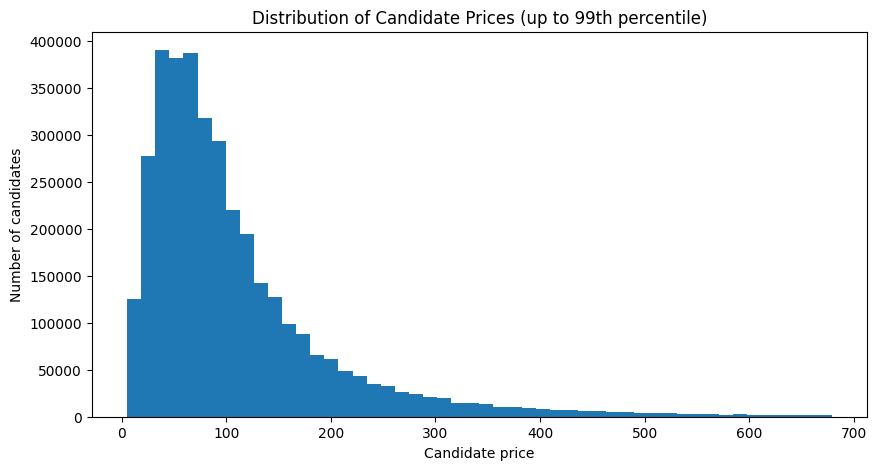

In [ ]:
# Visualise candidate price distribution up to the 99th percentile

price_99 = candidates["candidate_price"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    candidates.loc[
        candidates["candidate_price"] <= price_99,
        "candidate_price"
    ],
    bins=50
)

plt.xlabel("Candidate price")
plt.ylabel("Number of candidates")
plt.title("Distribution of Candidate Prices (up to 99th percentile)")

plt.show()

Absolute price is strongly right-skewed.

The key evidence is that the mean (€120.26) is considerably higher than the median (€82). Most candidate prices are relatively moderate: 75% are ≤€138, 90% ≤€231, and 95% ≤€325. But the upper tail extends all the way to €10,000, which pulls the mean and standard deviation upward.

### 5.2. Price by context:


In [ ]:
candidates.columns.tolist()

['user_id',
 'session_id',
 'timestamp',
 'step',
 'action_type',
 'reference',
 'platform',
 'city',
 'device',
 'current_filters',
 'impressions',
 'prices',
 'ranking_event_id',
 'candidate_id',
 'candidate_price',
 'candidate_position',
 'clicked',
 'item_id',
 'properties',
 'num_properties',
 'selected_filters',
 'filter_match']

In [ ]:
# Candidate price by city

city_price_summary = (
    candidates
    .groupby("city")["candidate_price"]
    .agg(
        candidate_count="count",
        mean_price="mean",
        median_price="median"
    )
)

# Keep cities with at least 1,000 candidate observations
city_price_summary = (
    city_price_summary[
        city_price_summary["candidate_count"] >= 1000
    ]
    .sort_values("median_price", ascending=False)
)

city_price_summary

,candidate_count,mean_price,median_price
city,,,
"Bora Bora, French Polynesia",1522,484.24,292.00
"Hakone, Japan",5265,401.52,280.00
"Key West, USA",3401,317.52,267.00
"Karuizawa, Japan",1269,261.07,221.00
"Cabo San Lucas, Mexico",1456,311.97,220.50
...,...,...,...
"Gangtok, India",1181,32.25,20.00
"Tirupati, India",1803,26.83,20.00
"Agra, India",1477,59.06,19.00


In [ ]:
# Distribution of median prices across cities

city_price_summary["median_price"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

,median_price
count,559.00
mean,81.81
std,42.01
min,18.00
10%,35.80
25%,50.00
50%,73.00
75%,108.00
90%,135.20
max,292.00


Across the 559 cities with at least 1,000 candidate observations:

- City price ranges from €18 to €292.
- 25% of cities have a median price of €50 or less.
- The median across cities is €73.
- 25% have a median price above €108.
- 10% have a median price of €135 or more.

This indicates that he meaning of an absolute price depends considerably on destination. A €100 candidate could be relatively expensive in one city but relatively cheap in another.

In [ ]:
# Candidate price by device

device_price_summary = (
    candidates
    .groupby("device")["candidate_price"]
    .agg(
        candidate_count="count",
        mean_price="mean",
        median_price="median"
    )
    .sort_values("median_price")
)

device_price_summary

,candidate_count,mean_price,median_price
device,,,
mobile,1975855,112.80,77.00
desktop,1324946,126.30,87.00
tablet,315215,141.58,101.00


There is a noticeable price difference by device:

- Mobile: median €77, mean €112.80
- Desktop: median €87, mean €126.30
- Tablet: median €101, mean €141.58

In [ ]:
candidates["platform"].nunique()

55

In [ ]:
# Candidate price by platform

platform_price_summary = (
    candidates
    .groupby("platform")["candidate_price"]
    .agg(
        candidate_count="count",
        mean_price="mean",
        median_price="median"
    )
)

platform_price_summary = platform_price_summary[
    platform_price_summary["candidate_count"] >= 1000
]

# Distribution of median prices across platforms
platform_price_summary["median_price"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

,median_price
count,54.00
mean,78.43
std,27.52
min,30.00
10%,41.30
25%,55.25
50%,77.50
75%,102.75
90%,111.10
max,137.00


The median platform price ranges from €30 to €137. The middle 50% of platforms range from about €55.25 to €102. So platform clearly captures some differences in the price environment, but city appears to be the stronger contextual factor based on these descriptive results.

### 5.3. Relative price within each impression set

In [ ]:
# Calculate median candidate price within each impression set

candidates["impression_median_price"] = (
    candidates
    .groupby("ranking_event_id")["candidate_price"]
    .transform("median")
)

# Calculate candidate price relative to the impression-set median

candidates["relative_price"] = (
    candidates["candidate_price"]
    / candidates["impression_median_price"]
)

In [ ]:
candidates["relative_price"].describe(
    percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
)

,relative_price
count,3616016.00
mean,1.19
std,1.52
min,0.02
1%,0.31
10%,0.60
25%,0.79
50%,1.00
75%,1.26
90%,1.78


In [ ]:
# Compare relative price for clicked and non-clicked candidates

relative_price_clicked = (
    candidates
    .groupby("clicked")["relative_price"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

relative_price_clicked

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
clicked,,,,,,,,,,,
0,3458290.00,1.19,1.49,0.02,0.80,1.00,1.27,1.78,2.33,4.60,326.74
1,157726.00,1.08,2.08,0.02,0.68,0.92,1.15,1.64,2.18,4.25,326.74


In [ ]:
# Test whether relative price differs significantly
# between clicked and non-clicked candidates

from scipy.stats import mannwhitneyu

clicked_relative_price = candidates.loc[
    candidates["clicked"] == 1,
    "relative_price"
]

non_clicked_relative_price = candidates.loc[
    candidates["clicked"] == 0,
    "relative_price"
]

stat, p = mannwhitneyu(
    clicked_relative_price,
    non_clicked_relative_price,
    alternative="two-sided"
)

print("Mann-Whitney U:", stat)
print("p-value:", p)

Mann-Whitney U: 229586221134.5
p-value: 0.0


Clicked candidates had a lower median relative price (0.92) than non-clicked candidates (1.000). A Mann–Whitney U test indicated that the relative-price distributions differed significantly (U = 229586221134.5, p < .001).

# Overall EDA Conclusions and Findings:

1. **Basic description of the data:** The data was released by Trivago, an online accommodations aggregator, as part of a machine learning competition (Mahajan, 2016). It was composed of three files: *train*, *test*, and *item_metadata*. The *train* file contained session information, showing for each session a sequence of actions taken by the user. The `clickout item` action represented a click on a particular shown accommodation, taking the user to a third-party travel provider. There could be multiple clickout events within a single session.

2. **The dataset is very large:** To reduce computational requirements while preserving within-session behavioural sequences, a 10% sample of complete sessions was randomly selected using a fixed random seed. All interaction rows belonging to each selected session were retained. Ranking events and their candidate sets were subsequently constructed within this session-level sample. This ensured that interactions preceding each ranking event remained available for analysis and feature construction.

3. **Ranking-level events:** Each `clickout item` action was treated as a ranking event, representing a set of accommodation candidates shown to the user at that point in the session. Initial exploration identified a very small number of sessions containing distinct clickout events with the same `step`, making their interaction sequence ambiguous. These sessions were excluded. Following this exclusion, `session_id + step` uniquely identified each ranking event and was used to construct `ranking_event_id`.

4. **EDA strategy:** The EDA approach included an initial high-level exploration, as described above, followed by a more detailed exploration intended to directly inform future data processing and modelling decisions. To do this, the EDA was divided into two main parts, with the first aimed at helping to define the direction of the research, and the second structured to support the chosen direction. This ensured an efficient and highly informative EDA.

5. **Research direction:** Based on the data (Mahajan, 2016) and academic research (Covington, Adams and Sargin, 2016; Adamczak et al., 2020; Nan, Parthasarathy and Wang, 2023; Zaidi, Rincon and Hassantabar, 2026), a two-stage recommender architecture was identified, consisting of candidate generation followed by candidate ranking. Since Trivago already supplies the candidate set through the `impressions` column, this project focuses on the ranking stage. The modelling objective is therefore to use preceding session behaviour, search context and candidate accommodation information to assign each candidate a relevance score and rank candidates so that the accommodation most likely to be clicked appears higher. This supports the research question of whether deep-learning approaches can improve session-based accommodation ranking compared with classical machine-learning approaches, and whether any improvement is sufficient to justify their additional complexity.

6. **Data quality and structural integrity were high:** No true duplicate records were identified in the source files. Missing values largely represented structural meaning rather than unexpected missingness. Candidate and price lists were correctly aligned, clickout references were largely consistent with the corresponding candidate lists, and property metadata coverage was very high, with only approximately 0.04% of candidate appearances lacking metadata. A small number of sampled sessions contained ambiguous repeated clickout steps and were excluded to ensure an unambiguous interaction sequence.

7. **Session behaviour:** The sampled data preserves complete interaction sequences within each selected session. Approximately 80% of ranking events were preceded by at least one interaction, including searches, filter selections and interactions with accommodation information, images, ratings and deals. To represent the most relevant recent behaviour, each ranking event was associated with the most recent sequence of non-clickout interactions preceding it. Consecutive clickouts without intervening behavioural actions share the same preceding behavioural sequence. This provides session-level behavioural information that can be incorporated into the ranking model while ensuring that only information available before or at the ranking event is used.

8. **Feature cardinality exploration:** Destination, mostly representing cities, is a high-cardinality feature, containing 12,320 unique values and highly dispersed. The most frequent city accounts for only 1.8% of potential ranking events. Direct categorical representation of city could therefore result in a high-dimensional and sparse feature space. Platform, which represents countries/geographic regions, contains 55 values, while device contains only three categories. Mobile (47.69%) and desktop (43.91%) are similarly represented, with tablet accounting for 8.07% of ranking events.

9. **Filters and accommodation attributes:** Filter-selection actions provide information about preferences or constraints expressed by users during their session, while the `properties` field in the accommodation metadata describes attributes associated with individual accommodations. Of the 130 unique filters selected before ranking events, 110 (84.6%) had a direct match in the accommodation-property vocabulary. A binary `filter_match` feature was therefore created to indicate whether at least one filter selected in the preceding behavioural sequence matched a candidate property. Filter information was not available for all ranking events, meaning that it may provide useful intent information when present but cannot be relied upon as a consistently available ranking signal.

10. **Association between features:** Platform and destination city are strongly associated. Cramér's V of 0.705 indicates substantial association between the two features. In contrast, platform and device showed only a weak association (Cramér's V = 0.183), suggesting that platform and device capture largely different contextual information.

11. **Candidate position:** Candidate position has a strong relationship with click behaviour. Candidates in the first position had a click-through rate of approximately 32%, compared with 11% in the second position and 8% in the third, with click rate continuing to decline as position increased. Position is therefore a potentially strong ranking signal, although it should be treated carefully because the relationship may reflect the effectiveness of Trivago's existing ranking system and/or exposure bias.

12. **Candidates and preceding filter selections:** Candidates whose properties matched at least one filter selected in the preceding behavioural sequence had a click rate of 4.77%, compared with 4.33% for candidates without a match. A chi-square test found a statistically significant association between filter-property matching and click outcome, χ²(1) = 116.29, p < .001. However, the effect size was extremely small (Cramér's V = 0.006), indicating that filter-property matching alone has very limited explanatory value for click behaviour.

13. **Candidate price:** Candidate prices were strongly right-skewed, with an overall median of €82 compared with a mean of €119.94. While 90% of candidate prices were below €231 and 99% below €677, prices extended to €10,000. Clicked candidates also tended to have lower prices than non-clicked candidates, suggesting that price may provide a useful ranking signal. However, subsequent analysis showed that absolute price should be interpreted relative to the search context.

14. **Price and search context:** Absolute candidate price varied substantially across search contexts. Among 570 cities with at least 1,000 candidate observations, median candidate prices ranged from €15 to €302.50, with 50% of city-level medians falling between approximately €52 and €108. Price also differed by device, with median candidate prices of €76 for mobile, €86 for desktop and €101 for tablet. Platform-level median prices also varied, although less strongly than destination-level prices. These findings indicate that absolute price should be interpreted in the context in which a candidate is presented.

15. **Relative price:** Relative price was calculated by dividing each candidate's price by the median candidate price within the same ranking event. Clicked candidates had a median relative price of 0.917, compared with 1.000 for non-clicked candidates, indicating that clicked accommodations tended to be cheaper relative to the alternatives presented within the same ranking event. A Mann–Whitney U test indicated that the relative-price distributions differed significantly (U = 233,107,802,207, p < .001). Given the very large sample size, effect size and differences in click rates across relative-price levels should also be considered when assessing the practical importance of this relationship.

In [ ]:
# Final EDA checkpoint: validate and save all datasets used in preprocessing

clickouts.to_parquet(
    f"{DATA_PATH}/clickouts_sample.parquet",
    index=False
)

print("Final clickouts saved.")
print("Rows:", len(clickouts))
print("Ranking events:", clickouts["ranking_event_id"].nunique())

Final clickouts saved.
Rows: 157809
Ranking events: 157809


In [ ]:
# Save final session-events dataset

session_events.to_parquet(
    f"{DATA_PATH}/session_events_sample.parquet",
    index=False
)

print("Final session events saved.")
print("Rows:", len(session_events))
print(
    "Ranking events:",
    session_events["ranking_event_id"].nunique()
)

Final session events saved.
Rows: 1568261
Ranking events: 157809


In [ ]:
# Save final candidate-level dataset

candidates.to_parquet(
    f"{DATA_PATH}/candidates.parquet",
    index=False
)

print("Final candidates saved.")
print("Rows:", len(candidates))
print(
    "Ranking events:",
    candidates["ranking_event_id"].nunique()
)

Final candidates saved.
Rows: 3616016
Ranking events: 157809
